### ASSIGNMENT No: 11

Title: For an image classification challenge, create and train a ConvNet in Python using TensorFlow. Also, try to improve the performance of the model by applying various hyper parameter tuning to reduce the overfitting or under fitting problem that might occur. Maintain graphs of comparisons.

Problem Statement:  Implement an image classification challenge, create and train a ConvNet in Python using TensorFlow 

In [12]:
# !pip install numpy matplotlib tensorflow opencv-python

# (Latest version upgrade)
# !pip install -U numpy matplotlib tensorflow opencv-python

#If tensorflow installation takes time
# !pip install tensorflow-cpu

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
# from tensorflow.keras.datasets import fashion_mnist (If you are using fashion Mnist uncomment this and delete cifar10)


In [14]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data() (If you are using fashion Mnist uncomment this and delete cifar10)

# Normalize data (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [15]:
# Use this only when fashion mnist
# x_train = x_train.reshape(-1, 28, 28, 1)
# x_test = x_test.reshape(-1, 28, 28, 1)

In [16]:
def create_model(filters=32, dropout_rate=0.0):
    model = models.Sequential([
        layers.Conv2D(filters, (3,3), activation='relu', input_shape=(32,32,3)),
        # layers.Conv2D(filters, (3,3), activation='relu', input_shape=(28,28,1)), (for fashion MNIST) (Delete above layer if using fashion MNIST)
        layers.MaxPooling2D((2,2)),
        
        layers.Conv2D(filters*2, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        
        layers.Dropout(dropout_rate),  # helps reduce overfitting
        
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [17]:
model1 = create_model(filters=32, dropout_rate=0.0)

history1 = model1.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4270 - loss: 1.5870 - val_accuracy: 0.5238 - val_loss: 1.3423
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5599 - loss: 1.2469 - val_accuracy: 0.6098 - val_loss: 1.1283
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6143 - loss: 1.0976 - val_accuracy: 0.6422 - val_loss: 1.0330
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6518 - loss: 1.0050 - val_accuracy: 0.6500 - val_loss: 1.0213
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6763 - loss: 0.9362 - val_accuracy: 0.6722 - val_loss: 0.9619


In [18]:
model2 = create_model(filters=32, dropout_rate=0.5)

history2 = model2.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.2912 - loss: 1.8733 - val_accuracy: 0.4526 - val_loss: 1.5364
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4025 - loss: 1.6079 - val_accuracy: 0.5052 - val_loss: 1.3910
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4527 - loss: 1.4907 - val_accuracy: 0.5518 - val_loss: 1.2552
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4795 - loss: 1.4087 - val_accuracy: 0.5900 - val_loss: 1.1641
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5050 - loss: 1.3550 - val_accuracy: 0.6052 - val_loss: 1.1136


In [19]:
print("Without Dropout Accuracy:", history1.history['val_accuracy'][-1])
print("With Dropout Accuracy:", history2.history['val_accuracy'][-1])

Without Dropout Accuracy: 0.6722000241279602
With Dropout Accuracy: 0.6051999926567078


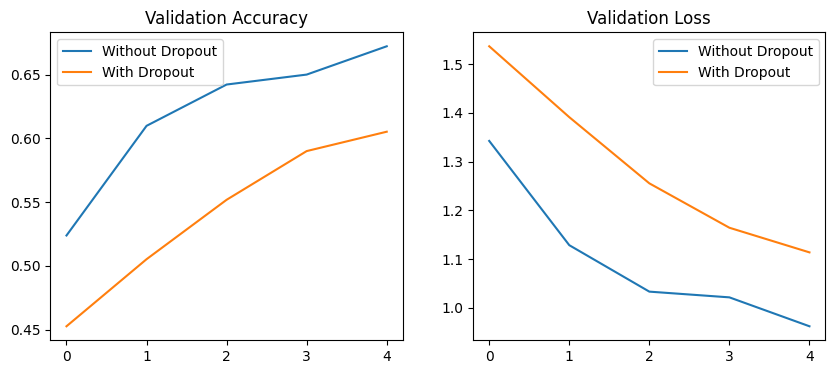

In [20]:
plt.figure(figsize=(10,4))

# Accuracy comparison
plt.subplot(1,2,1)
plt.plot(history1.history['val_accuracy'], label='Without Dropout')
plt.plot(history2.history['val_accuracy'], label='With Dropout')
plt.title("Validation Accuracy")
plt.legend()

# Loss comparison
plt.subplot(1,2,2)
plt.plot(history1.history['val_loss'], label='Without Dropout')
plt.plot(history2.history['val_loss'], label='With Dropout')
plt.title("Validation Loss")
plt.legend()

plt.show()

In [21]:
loss, acc = model2.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5985 - loss: 1.1324
Test Accuracy: 0.5985000133514404


In [22]:
import cv2
import numpy as np

# Image path (keep image.jpg in same folder)
img = cv2.imread("image.jpg")

# -------------------------------
# 🔹 For CIFAR-10 (RGB images)
# -------------------------------
img = cv2.resize(img, (32, 32))  # CIFAR uses 32x32 size
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR → RGB
img = img / 255.0  # Normalize

# -------------------------------
# 🔹 For Fashion-MNIST (Grayscale)
# -------------------------------
# Uncomment below and comment CIFAR part if using Fashion-MNIST
# img = cv2.resize(img, (28, 28))           # Fashion MNIST uses 28x28
# img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
# img = img / 255.0
# img = img.reshape(28, 28, 1)              # Add channel dimension

# Add batch dimension (same for both)
img = np.expand_dims(img, axis=0)

# Predict
prediction = model2.predict(img)

# -------------------------------
# 🔹 Class Names
# -------------------------------
# CIFAR-10 classes (currently active)
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

# For Fashion-MNIST (uncomment if using it)
# class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
#                'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Get predicted class
pred_class = class_names[np.argmax(prediction)]

print("Predicted Class:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Predicted Class: Automobile


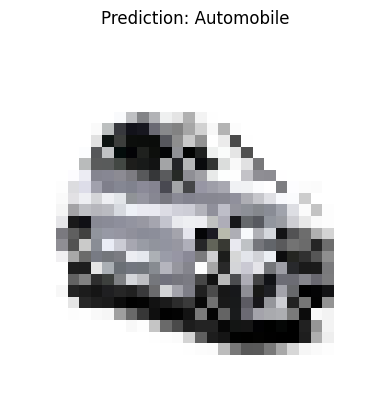

In [23]:
plt.imshow(img[0])
plt.title(f"Prediction: {pred_class}")
plt.axis('off')
plt.show()